In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cat.jpg to cat.jpg


In [ ]:
from PIL import Image
image1=Image.open('cat.jpg')

GIT IMAGE CAPTIONING

PGD ATTACK

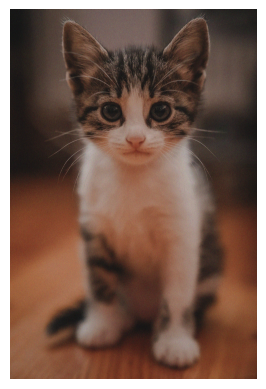

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image_path = "cat.jpg"  # Replace with your image path
image = Image.open(image_path).convert("RGB")

# Define transformations (keeping the original size)
transform = transforms.Compose([transforms.ToTensor()])
input_tensor = transform(image).unsqueeze(0)
input_tensor.requires_grad = True  # Enable gradient tracking

# PGD Attack function
def pgd_attack(image, epsilon=0.2, alpha=0.02, num_iters=10):
    perturbed_image = image.clone().detach()
    perturbed_image.requires_grad = True

    for _ in range(num_iters):
        noise = torch.randn_like(perturbed_image) * alpha  # Generate noise
        perturbed_image = perturbed_image + noise  # Add noise
        perturbation = torch.clamp(perturbed_image - image, -epsilon, epsilon)
        perturbed_image = torch.clamp(image + perturbation, 0, 1)  # Keep pixel values valid

    return perturbed_image

# Apply PGD attack
epsilon = 0.2  # Perturbation limit
alpha = 0.05 # Step size
num_iters = 10  # Number of attack iterations
adv_image_tensor = pgd_attack(input_tensor, epsilon, alpha, num_iters)

# Convert adversarial image tensor to PIL format
adv_image_pil = transforms.ToPILImage()(adv_image_tensor.squeeze(0))

# Display the adversarial image
plt.imshow(adv_image_pil)
plt.axis("off")
# Save the adversarial image
adv_image_pil.save("adversarial_cat.jpg")


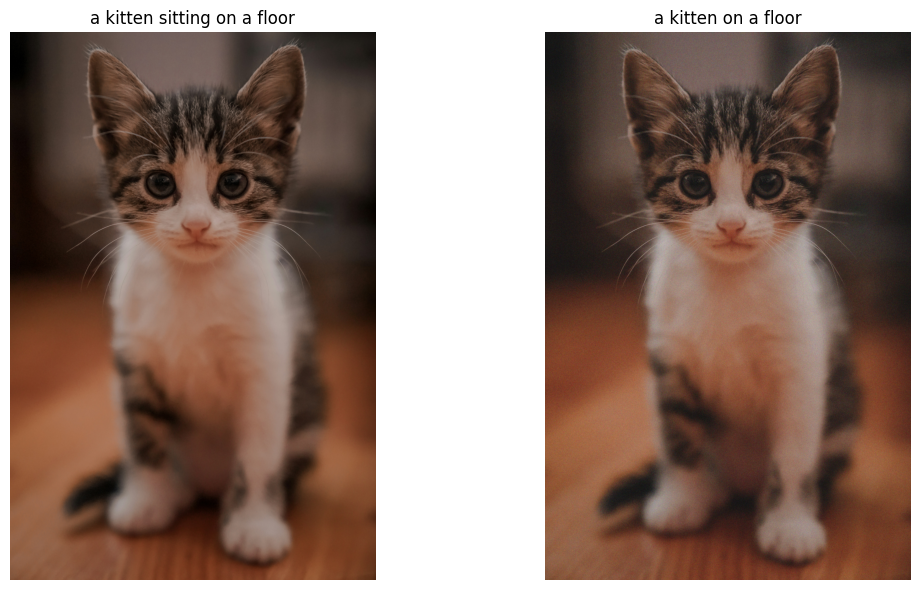

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load the GIT model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load two images
image_paths = ['cat.jpg', 'adversarial_cat.jpg']  # Replace with your image paths
images = [Image.open(img_path) for img_path in image_paths]

# Generate captions for both images
captions = []
for img in images:
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(**inputs)
    captions.append(processor.batch_decode(output, skip_special_tokens=True)[0])

# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(captions[i], fontsize=12, color='black')
    ax.axis('off')

plt.tight_layout()
plt.show()


FGSM ATTACK

In [ ]:
import torch
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load an image
image_path = "cat.jpg"  # Replace with your image path
image = Image.open(image_path).convert("RGB")

# Define transformations (keep the original size)
transform = transforms.Compose([transforms.ToTensor()])
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
input_tensor.requires_grad = True  # Enable gradient tracking

# Dummy model (for demonstration, replace with an actual model)
class SimpleModel(torch.nn.Module):
    def forward(self, x):
        return torch.sum(x, dim=[1, 2, 3])  # Fake "prediction"

model = SimpleModel()
model.eval()

# Generate a fake label (for demonstration)
target = torch.tensor([1.0], requires_grad=False)

# Compute loss
output = model(input_tensor)
loss = F.mse_loss(output, target)

# Compute gradients
loss.backward()

# FGSM Attack function
def fgsm_attack(image, epsilon):
    """
    Apply Fast Gradient Sign Method (FGSM) attack.
    Args:
        image: Original image tensor.
        epsilon: Perturbation magnitude.
    Returns:
        Adversarial image tensor.
    """
    sign_data_grad = image.grad.sign()  # Get the sign of the gradient
    perturbed_image = image + epsilon * sign_data_grad  # Add perturbation
    perturbed_image = torch.clamp(perturbed_image, 0, 1)  # Keep pixel values in range
    return perturbed_image

# Apply FGSM attack
epsilon = 0  # Set perturbation magnitude
adv_image_tensor = fgsm_attack(input_tensor, epsilon)

# Convert adversarial image tensor to PIL format
adv_image_pil = transforms.ToPILImage()(adv_image_tensor.squeeze(0))

# Save the adversarial image
adv_image_pil.save("adversarial_cat_fgsm.jpg")


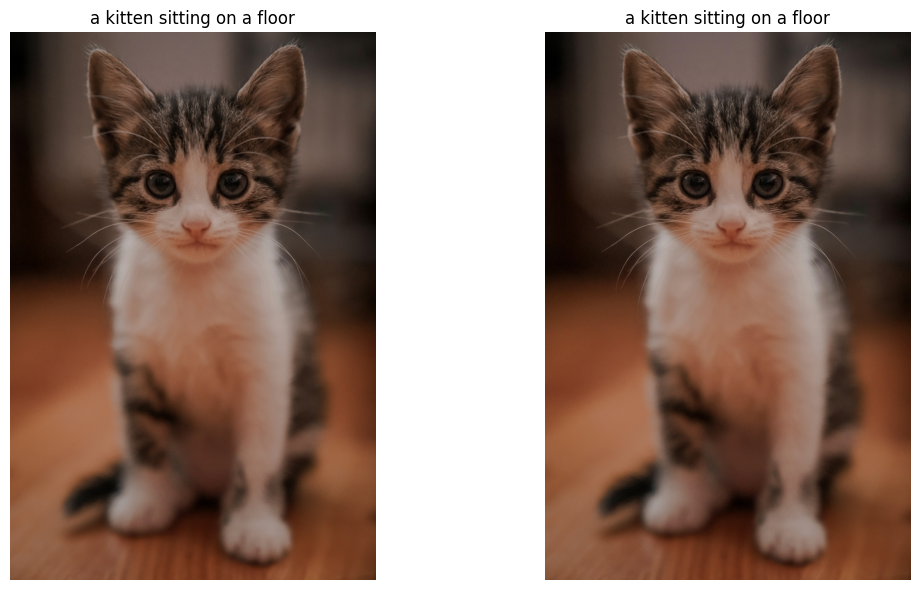

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load the GIT model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load two images
image_paths = ['cat.jpg', 'adversarial_cat_fgsm.jpg']  # Replace with your image paths
images = [Image.open(img_path) for img_path in image_paths]

# Generate captions for both images
captions = []
for img in images:
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(**inputs)
    captions.append(processor.batch_decode(output, skip_special_tokens=True)[0])

# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(captions[i], fontsize=12, color='black')
    ax.axis('off')

plt.tight_layout()
plt.show()


CW ATTACK

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load pretrained model (ResNet-18)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True).to(device)
model.eval()

# Image preprocessing (no resizing)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load image
image_path = "cat.jpg"  # Replace with your image path
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)
input_tensor = input_tensor.clone().detach().float()
input_tensor.requires_grad = False

# Get original prediction
with torch.no_grad():
    output = model(input_tensor)
original_label = torch.argmax(output, dim=1)

# Target label for CW attack (choose a different class for targeted attack)
target_label = torch.tensor([original_label.item() + 1 % 1000]).to(device)

# CW Attack Function
def cw_attack(model, image, target_label, c=5, lr=0.01, max_iters=20):
    perturbed_image = image.clone().detach().to(device)
    perturbed_image.requires_grad = True

    optimizer = optim.Adam([perturbed_image], lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(max_iters):
        optimizer.zero_grad()
        output = model(perturbed_image)
        loss = c * loss_fn(output, target_label)
        loss.backward()
        optimizer.step()

        # Clamp values between 0 and 1
        with torch.no_grad():
            perturbation = torch.clamp(perturbed_image - image, -0.03, 0.03)
            perturbed_image.copy_(torch.clamp(image + perturbation, 0, 1))

    return perturbed_image.detach()

# Apply CW Attack
adv_tensor = cw_attack(model, input_tensor, target_label)

# Save adversarial image
adv_image = transforms.ToPILImage()(adv_tensor.squeeze(0).cpu())
adv_image.save("adversarial_cat_cw.jpg")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.82k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/707M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the last token (EOS token) of the input_ids and attention_mask tensors will be removed. To test the new behavior, set `legacy=False`as a processor call argument.


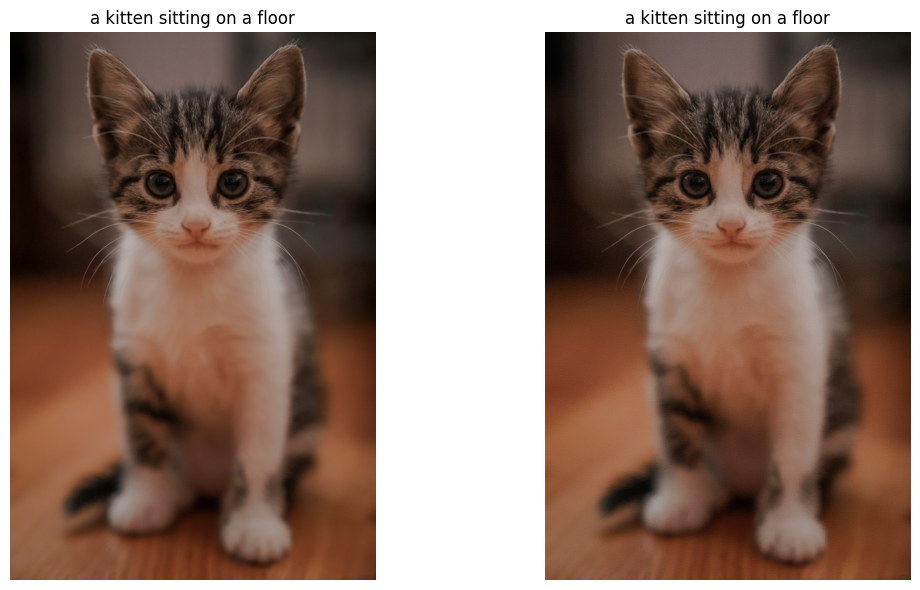

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load the GIT model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load two images
image_paths = ['cat.jpg', 'adversarial_cat_cw.jpg']  # Replace with your image paths
images = [Image.open(img_path) for img_path in image_paths]

# Generate captions for both images
captions = []
for img in images:
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(**inputs)
    captions.append(processor.batch_decode(output, skip_special_tokens=True)[0])

# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(captions[i], fontsize=12, color='black')
    ax.axis('off')

plt.tight_layout()
plt.show()

JSMA ATTACK

In [ ]:
import torch
import torchvision.transforms as T
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load image and apply transformation
def load_image(image_path):
    img = Image.open(image_path)
    transform = T.Compose([
        T.Resize((224, 224)),  # Resize to fit typical model input size (e.g., ResNet)
        T.ToTensor()
    ])
    return transform(img).unsqueeze(0)  # Add batch dimension

# Simulate JSMA-like attack
def jsma_attack(image_tensor, epsilon=0.05):
    # Ensure tensor requires gradient for saliency computation
    image_tensor.requires_grad = True

    # Dummy loss function: sum of all pixels (just for simulating gradient)
    loss = image_tensor.sum()
    loss.backward()

    # Saliency map: magnitude of gradient (how much each pixel contributes to loss)
    saliency = image_tensor.grad.data.abs()

    # Normalize saliency map
    saliency = saliency / saliency.max()

    # Apply perturbation based on saliency map
    perturbation = epsilon * saliency
    adv_img_tensor = image_tensor.detach() + perturbation

    # Clamp values to be valid pixel values [0, 1]
    adv_img_tensor = torch.clamp(adv_img_tensor, 0, 1)

    return adv_img_tensor

# Save the adversarial image as a .jpg file
def save_adversarial_image(adversarial_img_tensor, output_path):
    # Convert tensor back to a PIL image
    adv_img_pil = T.ToPILImage()(adversarial_img_tensor.squeeze(0))

    # Save the image in .jpg format
    adv_img_pil.save(output_path, 'JPEG')

# Example usage
image_path = 'cat.jpg'  # Replace with your image path
output_path = 'adversarial_image.jpg'  # Path to save the adversarial image

# Load original image
original_image = load_image(image_path)

# Apply JSMA attack
adversarial_image = jsma_attack(original_image)

# Save the adversarial image as a .jpg file
save_adversarial_image(adversarial_image, output_path)

print(f"Adversarial image saved as {output_path}")


Adversarial image saved as adversarial_image.jpg


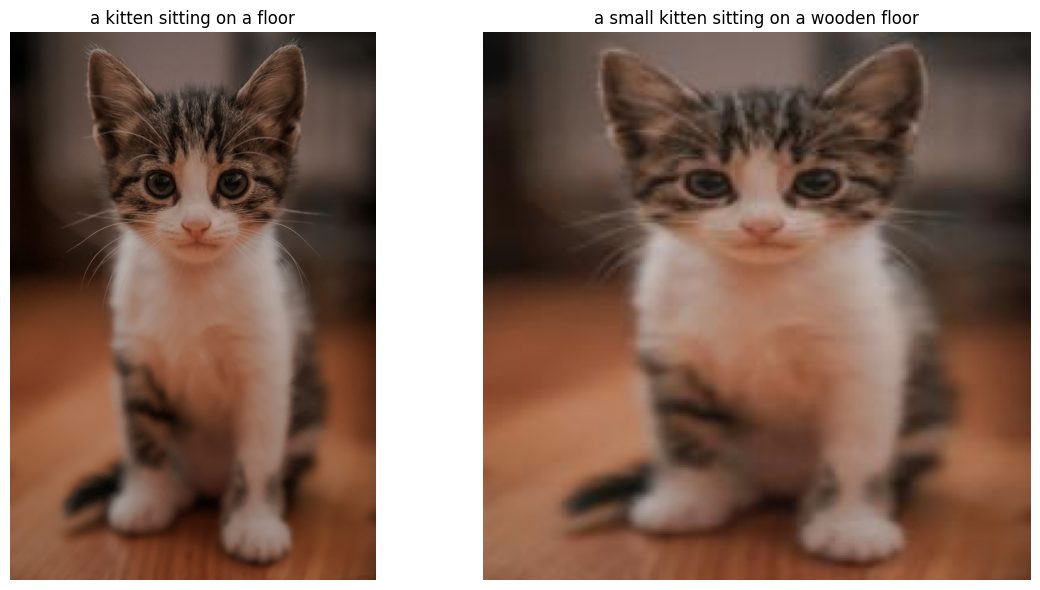

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load the GIT model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load two images
image_paths = ['cat.jpg', 'adversarial_image.jpg']  # Replace with your image paths
images = [Image.open(img_path) for img_path in image_paths]

# Generate captions for both images
captions = []
for img in images:
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(**inputs)
    captions.append(processor.batch_decode(output, skip_special_tokens=True)[0])

# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(captions[i], fontsize=12, color='black')
    ax.axis('off')

plt.tight_layout()
plt.show()


ONE PIXEL ATTACK

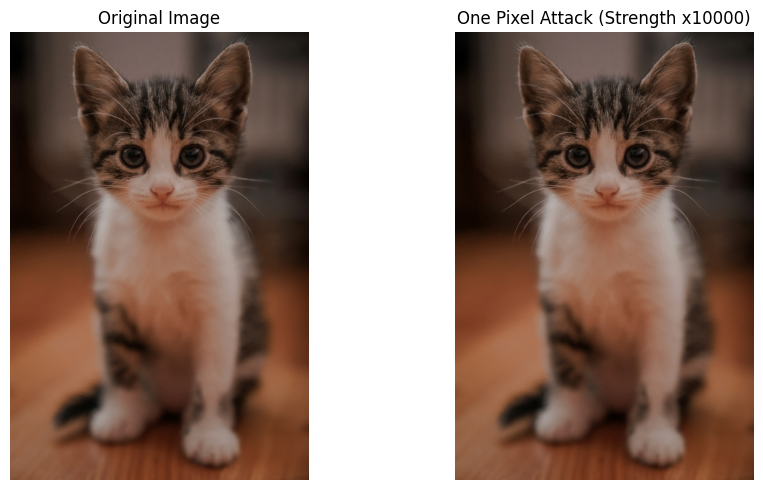

In [ ]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from PIL import Image

# Load image using PIL to remove EXIF orientation (if any)
image_path = 'cat.jpg'  # Replace with your image path
pil_image = Image.open(image_path)

# Convert to RGB (PIL uses RGB, while OpenCV uses BGR)
image_rgb = np.array(pil_image.convert("RGB"))

# Clone the original image for perturbation
perturbed_image = image_rgb.copy()

# Get image dimensions
height, width, _ = perturbed_image.shape

# Number of pixels to perturb
num_pixels = 10000  # You can adjust this to increase or decrease the number of pixels affected

# Apply the perturbation to multiple random pixels
for _ in range(num_pixels):
    # Select one random pixel
    x = random.randint(0, width - 1)
    y = random.randint(0, height - 1)

    # Increase the strength by altering the color more drastically
    perturbed_image[y, x] = np.array([random.randint(0, 255),
                                      random.randint(0, 255),
                                      random.randint(0, 255)])

# Save the perturbed image
perturbed_path = 'perturbed_image.jpg'
cv2.imwrite(perturbed_path, cv2.cvtColor(perturbed_image, cv2.COLOR_RGB2BGR))

# Display the images correctly in Matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"One Pixel Attack (Strength x{num_pixels})")
plt.imshow(perturbed_image)
plt.axis('off')

plt.tight_layout()
plt.show()


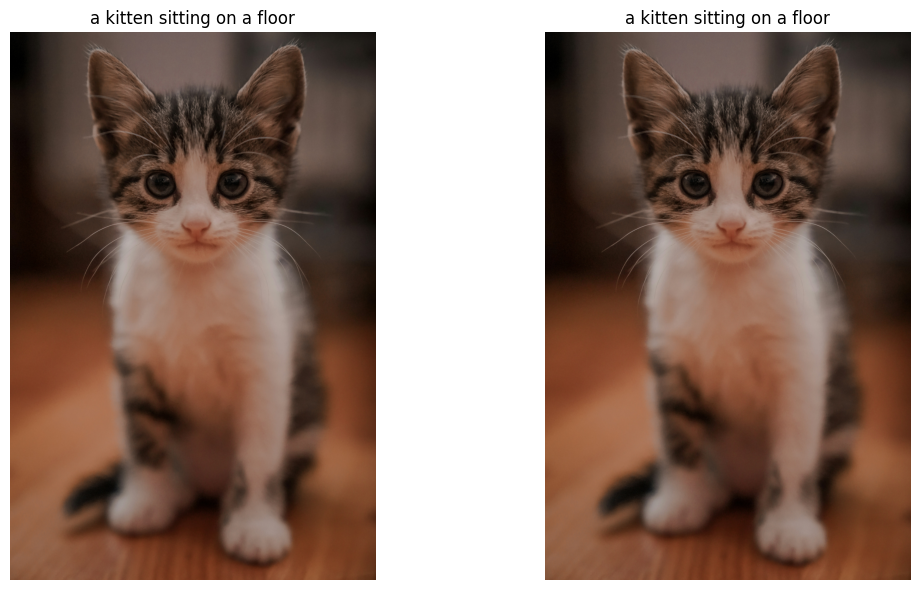

In [ ]:
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load the GIT model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load two images
image_paths = ['cat.jpg', 'perturbed_image.jpg']  # Replace with your image paths
images = [Image.open(img_path) for img_path in image_paths]

# Generate captions for both images
captions = []
for img in images:
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(**inputs)
    captions.append(processor.batch_decode(output, skip_special_tokens=True)[0])

# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(captions[i], fontsize=12, color='black')
    ax.axis('off')

plt.tight_layout()
plt.show()
